<h1>A use case in using LanguageChange to study lexical semantic change (diachronic) and variation (synchronic)</h1>
<p>We compare how two novels, Pride and Prejudice (1813) and Little Women (1868), and a multi-genre historical corpus (CCOHA) vary in their representation of a target word.</p>


# 1. Work with the data 

This part explains how we load the data into the LanguageChange library.



## Load Pride and Prejudice and Little Women from text data

We first load the data for Pride and Prejudice and Little Women downloaded from project Gutenberg. These files have already been tokenized and lemmatized.




In [18]:
from pathlib import Path

from languagechange.corpora import HistoricalCorpus, LinebyLineCorpus
from languagechange.utils import LiteralTime

target = "agreeable" # Target word we want to investigate
corpus_dir = Path("corpora") # Where our data is located

# Defines the paths to the novel corpora and their corresponding year labels.
novel_paths = [
    corpus_dir / "pp-tokens-lemmas.txt",
    corpus_dir / "lw-tokens-lemmas.txt",
]
novel_year_labels = [
    1813,
    1868,
]

# For each novel corpus, we load the data using our LinebyLineCorpus data loader. 
# We specify that the data is in English, already tokenized and lemmatized.
novel_corpora = []
for p, year in zip(novel_paths, novel_year_labels):
    corpus = LinebyLineCorpus(
        str(p),
        language="english",
        is_tokenized=True,
        is_lemmatized=True,
        time=LiteralTime(str(year)),
    )
    novel_corpora.append(corpus)

# We use the HistoricalCorpus class to combine the individual corpora into a single historical corpus. 
# This lets us compare the corpora across time later.
novels = HistoricalCorpus(novel_corpora)
print(novels)

# We can also unpack the individual corpora for easier access.
pp_corpus, lw_corpus = novel_corpora


HistoricalCorpus([<languagechange.corpora.LinebyLineCorpus object at 0x7df685555e90>, <languagechange.corpora.LinebyLineCorpus object at 0x7df68548ce10>], key=<function HistoricalCorpus.<lambda> at 0x7df68cdd28e0>)


## Load COHA data from parquet


Our COHA is in a different data Parquet format. Parquet is a tabular data format, where values are organized by rows and columns. Such a format is more optimal for computers to search through large datasets. 


| Token       | Lemma      | Part-of-speech |
|-------------|------------|----------------|
| The         | the        | DET            |
| unusual     | unusual    | ADJ            |
| mission     | mission    | NOUN           |
| for         | for        | PREP           |
| James       | james      | NOUN           |
| P.          | p.-a       | NOUN           |
| Rubin       | rubin      | NOUN           |
| takes       | take       | VERB           |
| advantage   | advantage  | NOUN           |
| of          | of         | PREP           |
| ties        | tie        | NOUN           |
| he          | he         | PRON           |
| developed   | develop    | VERB           |
| last        | last       | X              |
| year        | year       | NOUN           |
| ...          | ...         | ...           |

In order to load this dataset, we need to use a different loader in the LanguageChange library.

In [19]:
from languagechange.corpora import HistoricalCorpus, ParquetCorpus
from languagechange.utils import LiteralTime

# We load the CCOHA corpora, which are stored in parquet format. 
ccoha_paths = sorted(
    corpus_dir.glob("ccoha_*.parquet"),
    key=lambda p: int(p.stem.split("_")[1]),
)
# Keep track of the year labels for later use.
ccoha_year_labels = [int(p.stem.split("_")[1]) for p in ccoha_paths]

# For each CCOHA corpus, we load the data using our ParquetCorpus data loader.
ccoha_corpora = []
for p, year in zip(ccoha_paths, ccoha_year_labels):
    corpus = ParquetCorpus(
        str(p),
        time=LiteralTime(str(year)),
    )
    ccoha_corpora.append(corpus)

# We combine the individual CCOHA corpora into a single historical corpus, which we can use for analysis.
ccoha = HistoricalCorpus(ccoha_corpora)
print(ccoha)
print(f"Loaded {len(ccoha_corpora)} CCOHA slices: {ccoha_year_labels[0]}-{ccoha_year_labels[-1]}")


HistoricalCorpus([<languagechange.corpora.ParquetCorpus object at 0x7df685b9a650>, <languagechange.corpora.ParquetCorpus object at 0x7df68599b710>, <languagechange.corpora.ParquetCorpus object at 0x7df685999550>, <languagechange.corpora.ParquetCorpus object at 0x7df68599b250>], key=<function HistoricalCorpus.<lambda> at 0x7df68cdd28e0>)
Loaded 4 CCOHA slices: 1880-2000


<p>Keep everything together in one historical corpus spanning all available time points.</p>


In [1]:
from languagechange.corpora import HistoricalCorpus

all_corpora = HistoricalCorpus(novel_corpora + ccoha_corpora)
print(all_corpora)

NameError: name 'novel_corpora' is not defined

# Step 2: Sample target usages from text data

<p>Search for the target word in the novel corpus collection, the CCOHA collection, and the merged historical corpus. The same lemma-based query is used across both corpus formats.</p>


In [21]:
from languagechange.search import SearchTerm

# We define a search term for the target word we want to investigate. 
# In this case, we search for the lemma "agreeable", which will match all forms of the word (e.g., "agreeable", "agreeably", etc.).
search_term = SearchTerm(lemma=target)
term = str(search_term)
terms = {term}

# We search for the target word across all corpora and print the number of usages found in each corpus.
novel_usages = novels.search(search_term)
ccoha_usages = ccoha.search(search_term)
all_usages = all_corpora.search(search_term)

print(f"Found {len(all_usages[term])} usages of '{target}' across all corpora.")
print(f"Pride and Prejudice (1813): {len(pp_corpus.search(search_term)[term])}")
print(f"Little Women (1868): {len(lw_corpus.search(search_term)[term])}")
for year, corpus in zip(ccoha_year_labels, ccoha_corpora):
    year_usages = corpus.search(search_term)
    print(f"CCOHA {year}: {len(year_usages[term])}")


2026-06-10 14:38:00,660 - root - INFO - 45 usages found.
2026-06-10 14:38:00,718 - root - INFO - 22 usages found.
2026-06-10 14:38:01,220 - root - INFO - 67 usages found.
2026-06-10 14:38:02,208 - root - INFO - 80 usages found.
2026-06-10 14:38:02,844 - root - INFO - 19 usages found.
2026-06-10 14:38:03,473 - root - INFO - 8 usages found.
2026-06-10 14:38:03,512 - root - INFO - 45 usages found.
2026-06-10 14:38:03,571 - root - INFO - 22 usages found.
2026-06-10 14:38:04,042 - root - INFO - 67 usages found.
2026-06-10 14:38:04,971 - root - INFO - 80 usages found.
2026-06-10 14:38:05,491 - root - INFO - 19 usages found.
2026-06-10 14:38:05,979 - root - INFO - 8 usages found.
2026-06-10 14:38:06,015 - root - INFO - 45 usages found.
2026-06-10 14:38:06,068 - root - INFO - 22 usages found.


Found 241 usages of 'agreeable' across all corpora.
Pride and Prejudice (1813): 45
Little Women (1868): 22


2026-06-10 14:38:06,500 - root - INFO - 67 usages found.


CCOHA 1880: 67


2026-06-10 14:38:07,518 - root - INFO - 80 usages found.


CCOHA 1920: 80


2026-06-10 14:38:08,309 - root - INFO - 19 usages found.


CCOHA 1960: 19


2026-06-10 14:38:09,254 - root - INFO - 8 usages found.


CCOHA 2000: 8


<p>Sample up to 100 usages per time point for each collection. The CCOHA years are inferred directly from the discovered parquet filenames.</p>

In [22]:
from languagechange.usages import UsageDictionary
from languagechange.utils import LiteralTime

novel_years = [LiteralTime(str(y)) for y in novel_year_labels]
ccoha_years = [LiteralTime(str(y)) for y in ccoha_year_labels]
all_years = [LiteralTime(str(y)) for y in novel_year_labels + ccoha_year_labels]

novel_usages = UsageDictionary({
    term: novel_usages[term].sample_per_time(times=novel_years, n_samples=100)
    for term in terms
})
ccoha_usages = UsageDictionary({
    term: ccoha_usages[term].sample_per_time(times=ccoha_years, n_samples=100)
    for term in terms
})
all_usages = UsageDictionary({
    term: all_usages[term].sample_per_time(times=all_years, n_samples=100)
    for term in terms
})


<p>Optionally save the sampled usages for later reuse.</p>


In [23]:
novel_usages.save("usages/pp_lw_ccoha/novels")
ccoha_usages.save("usages/pp_lw_ccoha/ccoha")
all_usages.save("usages/pp_lw_ccoha/all")

# To load them again:
# novel_usages = UsageDictionary()
# novel_usages.load("usages/pp_lw_ccoha/novels")
# ccoha_usages = UsageDictionary()
# ccoha_usages.load("usages/pp_lw_ccoha/ccoha")
# all_usages = UsageDictionary()
# all_usages.load("usages/pp_lw_ccoha/all")


2026-06-10 14:38:09,499 - root - INFO - Usages written to usages/pp_lw_ccoha/novels/lemma=agreeable_usages.jsonl
2026-06-10 14:38:09,502 - root - INFO - Usages written to usages/pp_lw_ccoha/ccoha/lemma=agreeable_usages.jsonl
2026-06-10 14:38:09,505 - root - INFO - Usages written to usages/pp_lw_ccoha/all/lemma=agreeable_usages.jsonl


<p>Gather usages into two source collections for a direct comparison between the novels and CCOHA.</p>


In [24]:
source_comparison_usages = {
    term: {
        "novels": novel_usages[term],
        "ccoha": ccoha_usages[term],
    }
    for term in terms
}


# Step 3 and 4: Vectorize target usages and compare

<p>Define the contextualized representation model, the clustering algorithm, and the change metric.</p>


In [25]:
import torch
from languagechange.models.change.metrics import JSD
from languagechange.models.representation.contextualized import XL_LEXEME
from sklearn.cluster import AgglomerativeClustering


device = "cuda" if torch.cuda.is_available() else "cpu"

# We initialize the XL-LEXEME model, which is a contextualized embedding model designed for historical language data.
model = XL_LEXEME(device=device)

# We define the clustering algorithm we will use to cluster the contextualized embeddings of the usages.
clustering_algorithm = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.5,
    linkage="complete",
    metric="cosine",
)

# We initialize the JSD metric, which is a measure of distributional change 
# that we will use to quantify how much the meaning of the target word has changed over time.
metric = JSD()

2026-06-10 14:38:09,535 - languagechange.models.representation.contextualized - INFO - Initializing XL_LEXEME model.
2026-06-10 14:38:09,541 - WordTransformer.WordTransformer - INFO - Load pretrained SentenceTransformer: pierluigic/xl-lexeme


<p>Run the pipeline for the direct comparison between the two source collections.</p>


In [26]:
from languagechange.pipeline import CDPipeline

source_pipeline = CDPipeline(source_comparison_usages, model, metric, clustering_algorithm)
source_sampled_usages, source_embeddings, source_cluster_labels, source_change_scores = source_pipeline.run_pipeline()


2026-06-10 14:38:18,759 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_07c6e4a5dea1c628be3496dbcd89c6cf75a67eb4152e2f6c2beb8509d131e869.npy
2026-06-10 14:38:18,761 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_ea0acbe0ab8b0f50388c1a24cd7433eb2a346374422df87f2582482af172dc08.npy


# Step 5: Plot the results

In this part we plot clustering results across both text domain (syncronic-ish) and time (diacronic).

## Text domain comparison: CCOHA vs. Pride and Prejudice and Little Women

<p>Visualize the usage embeddings and clusters for the novels-versus-CCOHA comparison.</p>


2026-06-10 14:38:18,800 - root - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/reduced_embeddings/e035ec2b97b3ddc4262984417b46b4fa05a2b7fb369648e7a9f81308e30ccc01.npy


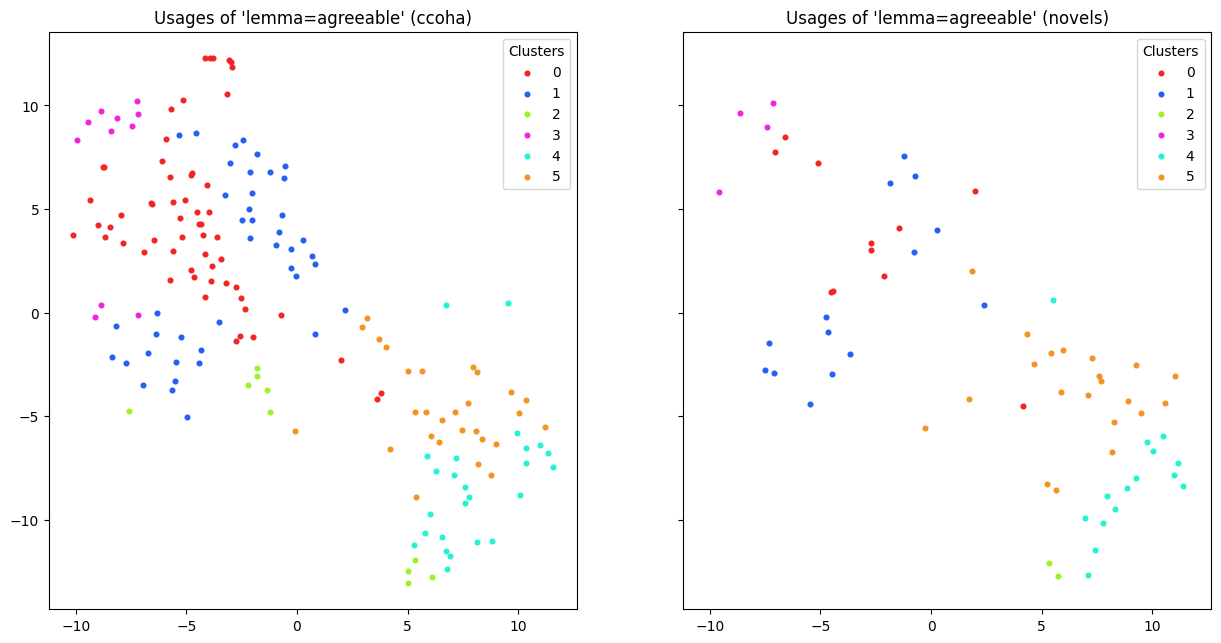

In [27]:
from languagechange.visualization import Visualizer

source_visualizer = Visualizer(
    usages=source_sampled_usages[term],
    embeddings=source_embeddings[term],
    cluster_labels=source_cluster_labels[term],
    target=term,
)

source_visualizer.plot_usage_embeddings()


<p>Inspect example usages from that comparison.</p>

In [28]:
source_visualizer.display_usages(max_usages=10, randomize=True)

Cluster 0:


1868:	When she went again , Mr. Dashwood was alone , whereat she rejoiced ; Mr. Dashwood was much wider awake than before , which was **agreeable** ; and Mr. Dashwood was not too deeply absorbed in a cigar to remember his manners : so the second interview was much more comfortable than the first .

1880:	Before Wilson 's strawberry came into vogue there were many other kinds which were sweeter and of a more **agreeable** flavor .

1920:	My good friend , Mrs. Talbot , " said Mrs. Lloyd , during their conversation , " has spoken of you so warmly that I could do no less than make overtures for an acquaintance , which I trust may prove **agreeable** .

1880:	There was but little time given him for indulgence in these soothing and **agreeable** reveries .

...

1813:	I knew it to be a most respectable , **agreeable** corps , and my friend Denny tempted me farther by his account of their present quarters , and the very great attentions and excellent acquaintance Meryton had procured them .

1813:	The Netherfield ladies would have had difficulty in believing that a man who lived by trade , and within view of his own warehouses , could have been so well bred and **agreeable** .

1813:	Mr. Collins to be sure was neither sensible nor **agreeable** ; his society was irksome , and his attachment to her must be imaginary .

1920:	Air you **agreeable** ? "

--------------------------------------------------------------------------------


## Time comparison: Across all time points

We now compare the clustering results by years: Pride and prejudice (1813), Little Women (1868), CCOHA 1880, 1920, 1960, 2000. 

The novels and CCOHA slices as are treated as one historical sequence and runs the pipeline across time.


In [29]:
from languagechange.pipeline import CDPipeline

merged_historical_usages = {
    term: {
        "english_texts": all_usages[term],
    }
    for term in terms
}

historical_pipeline = CDPipeline(merged_historical_usages, model, metric, clustering_algorithm)

years_per_time_period = 1

historical_sampled_usages, historical_embeddings, historical_cluster_labels, historical_change_scores = historical_pipeline.run_pipeline(
    time_period_length=years_per_time_period
)

2026-06-10 14:38:19,567 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_14b7bbdf0491d6884511e56a637f8a48500947ea214c45c4a1f1c79d14945047.npy
2026-06-10 14:38:19,569 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_ee20387e721c426353ff0f5b9789503cd7736a8fc5d6d9ae93a7fab0cba85424.npy
2026-06-10 14:38:19,571 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_22798191a5c3de4e0d2dc46eeeea59ba28a9059dbafe42e759e98fc4fdf31a65.npy
2026-06-10 14:38:19,573 - languagechange.models.representation.contextualized - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/contextualized/xl_lexeme_82cd5a979d1872b4b5dc5d240a7943b434709a2928c575955124cc954d5ef422.npy
2026-06-10 14:38

<p>Visualize the embeddings across the full historical sequence.</p>


2026-06-10 14:38:19,622 - root - INFO - Loading cached embeddings from /home/felix/.cache/languagechange/reduced_embeddings/b33c03170a8aff839c803b65877b70e838a7c73bd116d03ca7c8f2f86de3a5f4.npy


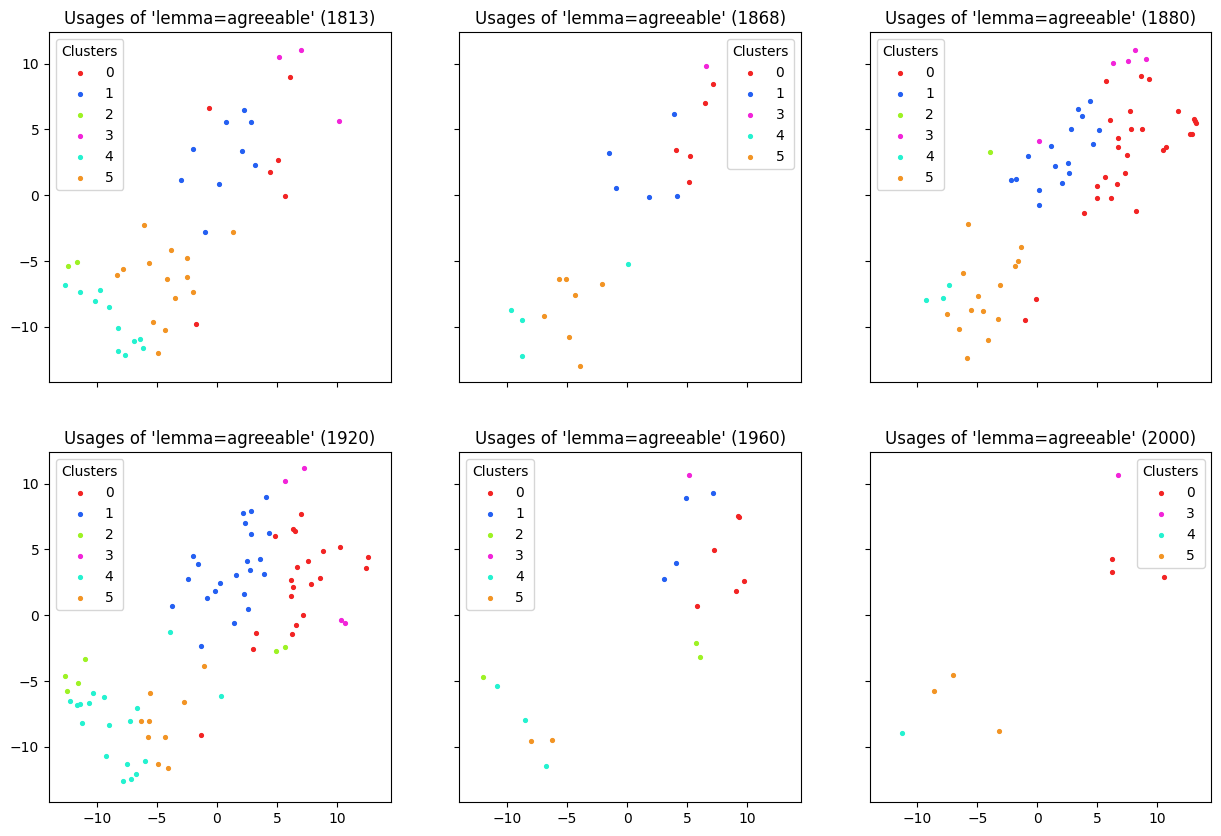

In [30]:
from languagechange.visualization import Visualizer

historical_visualizer = Visualizer(
    usages=historical_sampled_usages[term],
    embeddings=historical_embeddings[term],
    cluster_labels=historical_cluster_labels[term],
    target=term,
)

historical_visualizer.plot_usage_embeddings(target=term)


<p>Inspect example usages from the merged historical corpus.</p>


In [31]:
historical_visualizer.display_usages(max_usages=10, randomize=True)


Cluster 0:


1920:	If a man lacked the intelligence to learn the chemistry of foods and the esthetic capacity to prepare them so as to make life more enjoyable and **agreeable** , he might well pass for a worthy person , but he would have to acknowledge himself a dullard in the graces of life , and take the consequences . "

1868:	The little girls , however , considered it a most **agreeable** and interesting event , and Jo got little comfort from them ; so she went up to her refuge in the garret , and confided her troubles to the rats .

1880:	A racking cough was one of the peculiarities of my friend , and determined to assume the character in toto , I allowed myself to startle the silence now and then with a series of gasps and chokings that whether **agreeable** or not , certainly were of a

1880:	In the better kind of women there is a form of self-sacrifice which , between the course that is **agreeable** and the course that is repugnant , disposes them to think that they ought to choose the latter .

...

1813:	Mr. Wickham was the happy man towards whom almost every female eye was turned , and Elizabeth was the happy woman by whom he finally seated himself ; and the **agreeable** manner in which he immediately fell into conversation , though it was only on its being a wet night , and on the probability of a rainy season , made her feel that the commonest , dullest , most thread - bare topic might be rendered interesting by the skill of the speaker .

1813:	-- To find a man **agreeable** whom one is determined to hate !

1920:	" You fellows **agreeable** ? "

1920:	They regarded her as **agreeable** but green .

--------------------------------------------------------------------------------


## Plot rate of change for each year

<p>Plot the change score time series for the target word across the available time points.</p>


2026-06-10 14:38:20,819 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-10 14:38:20,822 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


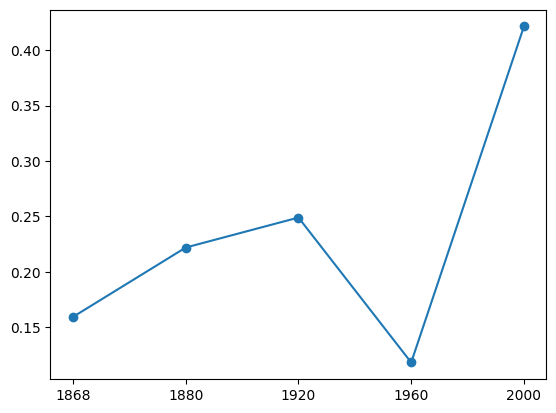

In [32]:
historical_change_scores[term].plot()
